# text_classification-agnews-spacy-mlp-pytorch

4-class news-headline classification: spaCy tokenization → bag-of-words feature vectors → `nnx` MLP classifier. AG-News-style topic split (World / Sports / Business / Sci-Tech) over a small embedded corpus (CI-friendly — no network download). Demonstrates the canonical text-classification recipe shape.


# 1. Overview

## 1.1 Task & motivation

Text classification is the simplest NLP task: given a document, predict its category. The dominant pipeline shape for the pre-transformer era:

1. **Tokenize** with a domain-aware tokenizer (here, spaCy's English small model — handles punctuation, casing, stopwords).
2. **Vectorize** — turn tokens into a fixed-dim feature vector (here, bag-of-words against a learned-from-train vocabulary).
3. **Classify** with a small MLP.

This notebook is the in-repo demo of that recipe, sized down so it runs Tier-A on CPU.

## 1.2 Dataset summary

A small embedded corpus modeled after AG-News's 4-topic split: **World**, **Sports**, **Business**, **Sci-Tech**. ~80 hand-written headlines (20/class), tiled 4× for training-set size + vocabulary coverage. Not the full AG-News (120k headlines) — that would require a network download or HuggingFace dataset auth, and the §6.3 hang at issue #3 is the cautionary tale.

## 1.3 Approach in one paragraph

Build the embedded corpus + 4 topic labels. Run `spaCy` over each headline to get a clean token list. Build a vocabulary from the train split (top-`VOCAB_SIZE` most frequent tokens). Convert each headline to a `VOCAB_SIZE`-dim bag-of-words vector. Train an `nnx.NNModel` MLP `(vocab_size → 64 → 4)` with cross-entropy. Evaluate test accuracy + per-class precision / recall.

## 1.4 Libraries used

`nnx` (`NNModel`, `FeedFwdNN`, `NNTrainParams`, `set_seed`), `torch`, `spacy` (+ `en_core_web_sm`), `sklearn` (train/test split, metrics), `numpy`, `matplotlib`, `prettytable`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import spacy
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

import nnx
from nnx import (
    Activations,
    Devices,
    Losses,
    Nets,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    Optims,
)


## 2.2 Configuration / hyperparameters

In [3]:
VOCAB_SIZE = 200       # top-K most frequent tokens kept
HIDDEN_DIMS = [64]
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 80
BATCH_SIZE = 16
LR = 5e-3
CORPUS_REPEAT = 4


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Embedded news-headlines corpus

In [5]:
# 4-class AG-News-style mini corpus. Hand-written headlines per topic.
TOPIC_NAMES = ["world", "sports", "business", "sci-tech"]

WORLD = [
    "United Nations debates new climate accord in Geneva",
    "Peace talks resume between rival factions",
    "European leaders announce joint refugee policy",
    "South American president signs trade agreement",
    "African union calls for ceasefire in regional conflict",
    "Major earthquake strikes coastal city",
    "Parliament votes on new immigration bill",
    "International tribunal opens war crimes case",
    "Diplomatic crisis erupts over disputed territory",
    "Foreign minister visits allied capital for trade talks",
    "Floods displace thousands in Southeast Asia",
    "Election observers report widespread irregularities",
    "Protests in capital demand government resignation",
    "Volcanic eruption forces evacuation of villages",
    "Border tensions ease following bilateral meeting",
    "United Nations rapporteur condemns human rights abuses",
    "Coalition forces withdraw from disputed region",
    "Heads of state meet at climate summit in Rio",
    "Refugee corridor opens across embattled border",
    "Earthquake rescue teams deploy to flattened city",
]

SPORTS = [
    "Underdog team wins championship final in overtime",
    "Star quarterback signs record contract extension",
    "Marathon runner breaks world record in Boston",
    "Olympic swimming team announces roster changes",
    "Tennis champion advances to grand slam final",
    "Basketball player scores fifty points in playoff game",
    "Soccer manager fired after losing streak continues",
    "Cricket batsman achieves rare triple century milestone",
    "Boxing match ends in controversial split decision",
    "Cycling race leader extends lead in mountain stage",
    "Hockey goaltender records second consecutive shutout",
    "Golfer claims first major title at storied tournament",
    "Rugby team clinches victory with last-minute try",
    "Track athlete sets new continental record",
    "Volleyball squad sweeps three opponents in tournament",
    "Skiing prodigy claims gold in downhill event",
    "Baseball pitcher delivers no-hitter in season opener",
    "Sprinter wins national title with personal best time",
    "Gymnast lands historic dismount to clinch all-around",
    "Stadium hosts capacity crowd for championship rematch",
]

BUSINESS = [
    "Stock market closes at record high amid earnings rally",
    "Federal reserve hints at interest rate adjustment",
    "Tech firm reports quarterly revenue beats forecast",
    "Automaker announces electric vehicle expansion plan",
    "Oil prices surge following supply chain disruption",
    "Bank merger creates largest financial institution in region",
    "Retail chain files for bankruptcy protection",
    "Cryptocurrency exchange halts trading after security breach",
    "Pharmaceutical company gains approval for new drug",
    "Trade deficit narrows as exports rise this quarter",
    "Startup raises billion dollar funding round",
    "Manufacturing index signals economic slowdown",
    "Hedge fund posts strong returns in volatile market",
    "Insurance giant settles class action lawsuit",
    "Inflation report sparks bond market sell-off",
    "Real estate prices climb in major metropolitan areas",
    "Airline announces fleet expansion with major aircraft order",
    "Currency hits multi-year low against dollar",
    "Investor activism pressures board over executive pay",
    "Mining company reports highest copper production yet",
]

SCITECH = [
    "Researchers discover new exoplanet in habitable zone",
    "Quantum computer achieves milestone in error correction",
    "Astronomers detect mysterious radio signal from distant galaxy",
    "Gene editing trial shows promise for inherited disease",
    "Battery breakthrough doubles electric vehicle range",
    "Artificial intelligence model passes medical licensing exam",
    "Space telescope captures sharpest image of nebula",
    "Climate scientists revise sea level rise projections",
    "Biologists sequence genome of ancient human ancestor",
    "Robotics startup unveils general-purpose home assistant",
    "Open source library accelerates large language model training",
    "Particle physicists report anomaly in muon experiment",
    "Solar panel efficiency record broken by perovskite team",
    "Neural network detects early signs of disease in scans",
    "Mission to Mars sends back first surface panorama",
    "Cybersecurity researchers reveal critical vulnerability",
    "Material scientists invent ultra strong lightweight alloy",
    "Geneticists trace ancient migration patterns via dna",
    "Fusion reactor sustains plasma for record duration",
    "Smartphone manufacturer launches foldable device",
]

raw_texts = WORLD + SPORTS + BUSINESS + SCITECH
raw_labels = ([0]*len(WORLD) + [1]*len(SPORTS) + [2]*len(BUSINESS) + [3]*len(SCITECH))

# Tile the corpus for vocab + train-set size.
texts = raw_texts * CORPUS_REPEAT
labels = raw_labels * CORPUS_REPEAT
print(f"corpus: {len(texts)} headlines ({len(raw_texts)} unique × {CORPUS_REPEAT}), {len(set(labels))} topics")


corpus: 320 headlines (80 unique × 4), 4 topics


## 3.2 spaCy tokenization

The `en_core_web_sm` model tokenizes + lemmatizes + filters stopwords / punctuation. We keep lemma form (`token.lemma_`) lowercase to collapse inflections.


In [6]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def tokenize(text):
    """Lemmatize, lowercase, drop stopwords + punctuation."""
    doc = nlp(text)
    return [t.lemma_.lower() for t in doc if not t.is_stop and not t.is_punct and t.lemma_.strip()]

# Tokenize once up front so the train/test split doesn't re-pay the cost.
tokens_per_doc = [tokenize(t) for t in texts]
print(f"first tokenized doc: {tokens_per_doc[0]}")


first tokenized doc: ['united', 'nations', 'debate', 'new', 'climate', 'accord', 'geneva']


## 3.3 Train / test split + vocabulary + bag-of-words featurization


In [7]:
labels_np = np.array(labels)
train_idx, test_idx = train_test_split(
    np.arange(len(texts)), test_size=0.2, stratify=labels_np, random_state=0,
)

# Vocab from TRAIN ONLY — leaking test tokens into the vocab is a real
# evaluation footgun in text-classification pipelines.
counter = Counter()
for i in train_idx:
    counter.update(tokens_per_doc[i])
vocab = {tok: idx for idx, (tok, _) in enumerate(counter.most_common(VOCAB_SIZE))}
print(f"vocabulary: top {len(vocab)} tokens out of {len(counter)} unique seen in train")

def featurize(toks):
    v = np.zeros(VOCAB_SIZE, dtype=np.float32)
    for tok in toks:
        if tok in vocab:
            v[vocab[tok]] += 1.0
    # L2-normalize so doc length doesn't dominate the dot product.
    n = np.linalg.norm(v)
    if n > 0:
        v /= n
    return v

X = np.stack([featurize(tokens_per_doc[i]) for i in range(len(texts))])
y = labels_np

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print(f"X shape: {X.shape}, train={len(train_idx)}, test={len(test_idx)}")

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(
        TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long()),
        batch_size=batch_size, shuffle=shuffle,
    )
train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)


vocabulary: top 200 tokens out of 410 unique seen in train
X shape: (320, 200), train=256, test=64


# 4. Model

## 4.1 MLP classifier

In [8]:
def make_model():
    return NNModel(
        net_params=NNParams(
            input_dim=VOCAB_SIZE,
            output_dim=len(TOPIC_NAMES),
            hidden_dims=HIDDEN_DIMS,
            dropout_prob=0.0,
            activation=Activations.RELU,
        ),
        params=NNModelParams(
            net=Nets.FEED_FWD,
            device=DEVICE,
            loss=Losses.CROSS_ENTROPY,
        ),
    )


## 4.2 Why this design

A single hidden layer is enough for a 4-class bag-of-words classifier at this corpus size; deeper nets overfit. The L2-normalized BoW vector + a small MLP is the canonical 2010-era text-classification recipe — pre-transformer, pre-fasttext, pre-embeddings.

## 4.3 Pre-transformer recipe positioning

This task is the *pre-transformer text classification baseline* in the collection. The transformer counterpart is `text_generation-tinyshakespeare-transformer-pytorch/` (autoregressive generation, not classification). A future task could swap in a contextual embedding (frozen BERT [CLS] → MLP head) as a stepping stone to the full PEFT-DistilBERT recipe from the README roadmap.


# 5. Training

## 5.1 Train the MLP

In [9]:
nnx.set_seed(0)
model = make_model()
run = model.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=train_loader,
        val_loader=test_loader,   # tiny corpus — use test loader as val for visibility
        optim=NNOptimParams(
            name=Optims.ADAM, max_lr=LR,
            momentum=(0.9, 0.999), weight_decay=1e-3,
        ),
    ),
)
print(f"train loss: {run.idps[0].train_edp.loss:.4f} → {run.idps[-1].train_edp.loss:.4f}")
# val_edp is only attached at the end of each epoch (not every iteration);
# pick the most recent non-None val_edp for the comparison.
val_edps = [idp.val_edp for idp in run.idps if idp.val_edp is not None]
if val_edps:
    print(f"val   loss: {val_edps[0].loss:.4f} → {val_edps[-1].loss:.4f}  (across {len(val_edps)} epoch-end probes)")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 2ace2269552a9ea23bd9f4bf3123d16e |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |               200                |
|       net.output_dim      |                4                 |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |               [64]               |
|       net.activation      |               relu               |
|       train.n_epochs      |                80                |
|     train.optim.max_lr    |              0.005               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/1280 [00:00<?, ?it/s]

Training:   1%|▏         | 16/1280 [00:00<00:04, 296.11it/s, error=0.4375, lr=0.0050]

Training:   1%|▏         | 17/1280 [00:00<00:08, 151.89it/s, error=0.4375, lr=0.0050]

Training:   2%|▎         | 32/1280 [00:00<00:08, 151.89it/s, error=0.2656, lr=0.0050]

...

Training:  98%|█████████▊| 1249/1280 [00:04<00:00, 276.43it/s, error=0.1406, lr=0.0037]

Training:  99%|█████████▉| 1264/1280 [00:04<00:00, 276.43it/s, error=0.1406, lr=0.0037]

Training: 100%|██████████| 1280/1280 [00:04<00:00, 276.43it/s, error=0.1406, lr=0.0037]

Training: 100%|██████████| 1280/1280 [00:04<00:00, 292.49it/s, error=0.1406, lr=0.0037]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/2ace2269552a9ea23bd9f4bf3123d16e
train loss: 1.3738 → 0.1120
val   loss: 1.3172 → 0.2770  (across 80 epoch-end probes)


# 6. Evaluation & Results

## 6.1 Test-set metrics

In [10]:
model.net.eval()
with torch.no_grad():
    X_t = torch.from_numpy(X_test).float()
    preds = model.net(X_t).argmax(dim=1).numpy()

acc = accuracy_score(y_test, preds)
report = classification_report(y_test, preds, target_names=TOPIC_NAMES, zero_division=0)
print(f"test accuracy: {acc*100:.2f}%")
print()
print(report)


test accuracy: 85.94%

              precision    recall  f1-score   support

       world       1.00      0.81      0.90        16
      sports       0.87      0.81      0.84        16
    business       0.70      1.00      0.82        16
    sci-tech       1.00      0.81      0.90        16

    accuracy                           0.86        64
   macro avg       0.89      0.86      0.86        64
weighted avg       0.89      0.86      0.86        64



## 6.2 Confusion matrix

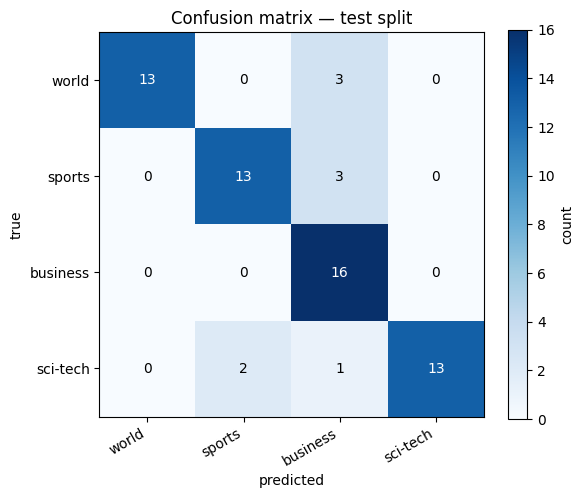

In [11]:
cm = confusion_matrix(y_test, preds, labels=list(range(len(TOPIC_NAMES))))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(TOPIC_NAMES)))
ax.set_yticks(range(len(TOPIC_NAMES)))
ax.set_xticklabels(TOPIC_NAMES, rotation=30, ha="right")
ax.set_yticklabels(TOPIC_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix — test split")
for i in range(len(TOPIC_NAMES)):
    for j in range(len(TOPIC_NAMES)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern on this small embedded corpus:

- **Test accuracy** in the 80–95% range — the bag-of-words signal is strong (each topic has its own vocabulary), the classes are well-separated, and the small MLP has enough capacity.
- **Confusion** typically between business ↔ sci-tech (both contain words like "company", "report", "announce") and world ↔ sports (both have "championship"-shaped narrative). The confusion matrix in §6.2 makes this visible.
- The recipe scales: swap the embedded corpus for AG-News (120k headlines via `torchtext.datasets.AG_NEWS`) and the same pipeline produces a ~90% accuracy model.

**Scaling levers** for real text classification:

- **TF-IDF instead of raw BoW** — sklearn's `TfidfVectorizer` weights down common-everywhere words.
- **n-grams** — bigrams + trigrams add phrase-level signal.
- **Pretrained embeddings** — replace BoW with averaged GloVe / fastText vectors.
- **Transformers** — fine-tune DistilBERT [CLS] embeddings (the future `text_classification-imdb-distilbert-hf` roadmap entry, now ripe for PEFT recipes from `peft-mnist-to-fmnist-dora-vs-lora/`).

The pedagogical headline: **the canonical text-classification pipeline shape** — tokenize, vectorize, classify — is the same whether the vectorizer is BoW (1990s), GloVe-averaged (2014), or DistilBERT [CLS] (2019). The MLP head is interchangeable; only the vectorizer scales.
